# 2. Dynamic simulation and target grid

This notebook reproduces the report's dynamic target-grid experiment under

\[
L_{\mathrm{execution}}=2T_{\mathrm{execution}},
\qquad
L_{\mathrm{data}}=90\text{M}.
\]

This is a fixed one-half execution target-to-limit ratio, not the physical three-second slot-time scenario. The notebook runs the exact bundle-priced EIP-7999 fee controller, BAL-inclusive demand, parent–BAL-consistent packing, 32 paired paths, one burn-in day, and seven measured days.

In [1]:
from pathlib import Path
import os
import subprocess
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src").is_dir() and (candidate / "scripts").is_dir():
            return candidate
    raise RuntimeError("Could not locate the repository root")

PROJECT_ROOT = find_project_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / "src"
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
for path in (SRC_DIR, SCRIPTS_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

DATA_DIR = PROJECT_ROOT / "data"
OUT_DIR = DATA_DIR / "7999"
PLOTS_DIR = PROJECT_ROOT / "plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

REFRESH_FROM_NETWORK = (
    os.environ.get("REFRESH_7999_SIMULATION_FROM_NETWORK", "0") == "1"
)
REUSE_OUTPUTS = os.environ.get("REUSE_7999_SIMULATION_OUTPUTS", "0") == "1"

def run_script(script: str, *args: str) -> None:
    command = [sys.executable, str(SCRIPTS_DIR / script), *map(str, args)]
    print("+", " ".join(command))
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)

print("project root:", PROJECT_ROOT)
print("network refresh:", REFRESH_FROM_NETWORK)
print("reuse generated outputs:", REUSE_OUTPUTS)

project root: /Users/william/PycharmProjects/eip-7999-research
network refresh: False
reuse generated outputs: True


## Run the 63-cell target grid

By default this reruns the simulation and replaces the ignored result CSVs. Set REUSE_7999_SIMULATION_OUTPUTS=1 only when validating an existing local run.

In [2]:
import run_multiscale_design_surface

surface_path = OUT_DIR / "design_surface.csv"
if not REUSE_OUTPUTS:
    run_multiscale_design_surface.main()
elif not surface_path.exists():
    raise FileNotFoundError(
        f"{surface_path.relative_to(PROJECT_ROOT)} does not exist; rerun without "
        "REUSE_7999_SIMULATION_OUTPUTS=1"
    )

surface = pd.read_csv(surface_path)
grid = surface[np.isclose(surface["data_limit"], 90e6)].copy()
assert len(grid) == 63
demand = pd.read_csv(OUT_DIR / "bal_decomposition_demand_parameters.csv").iloc[0]
anchor = pd.read_csv(OUT_DIR / "data_metering_runtime_bal_anchor.csv").iloc[0]
probe = run_multiscale_design_surface._build_config(
    [(150e6, 22.5e6)], 90e6, demand, anchor
)
assert probe.execution_limit[0] == 2 * probe.execution_target[0]
display(
    grid[[
        "execution_target", "data_target", "execution_fill",
        "data_limit_hit_fraction", "execution_floor_bounded_fraction",
        "execution_price_sd", "data_price_sd",
    ]].head()
)

,execution_target,data_target,execution_fill,data_limit_hit_fraction,execution_floor_bounded_fraction,execution_price_sd,data_price_sd
0,150000000.0,22500000.0,0.957009,0.001364,0.288093,0.032273,0.029414
1,150000000.0,29970000.0,0.994287,0.007034,0.031405,0.044612,0.039639
2,150000000.0,36000000.0,0.997653,0.019031,0.013172,0.047121,0.046994
3,150000000.0,45000000.0,0.999393,0.058262,0.004575,0.047485,0.056443
4,150000000.0,52470000.0,0.999837,0.116461,0.001551,0.046497,0.065261


## Reproduce the report figures

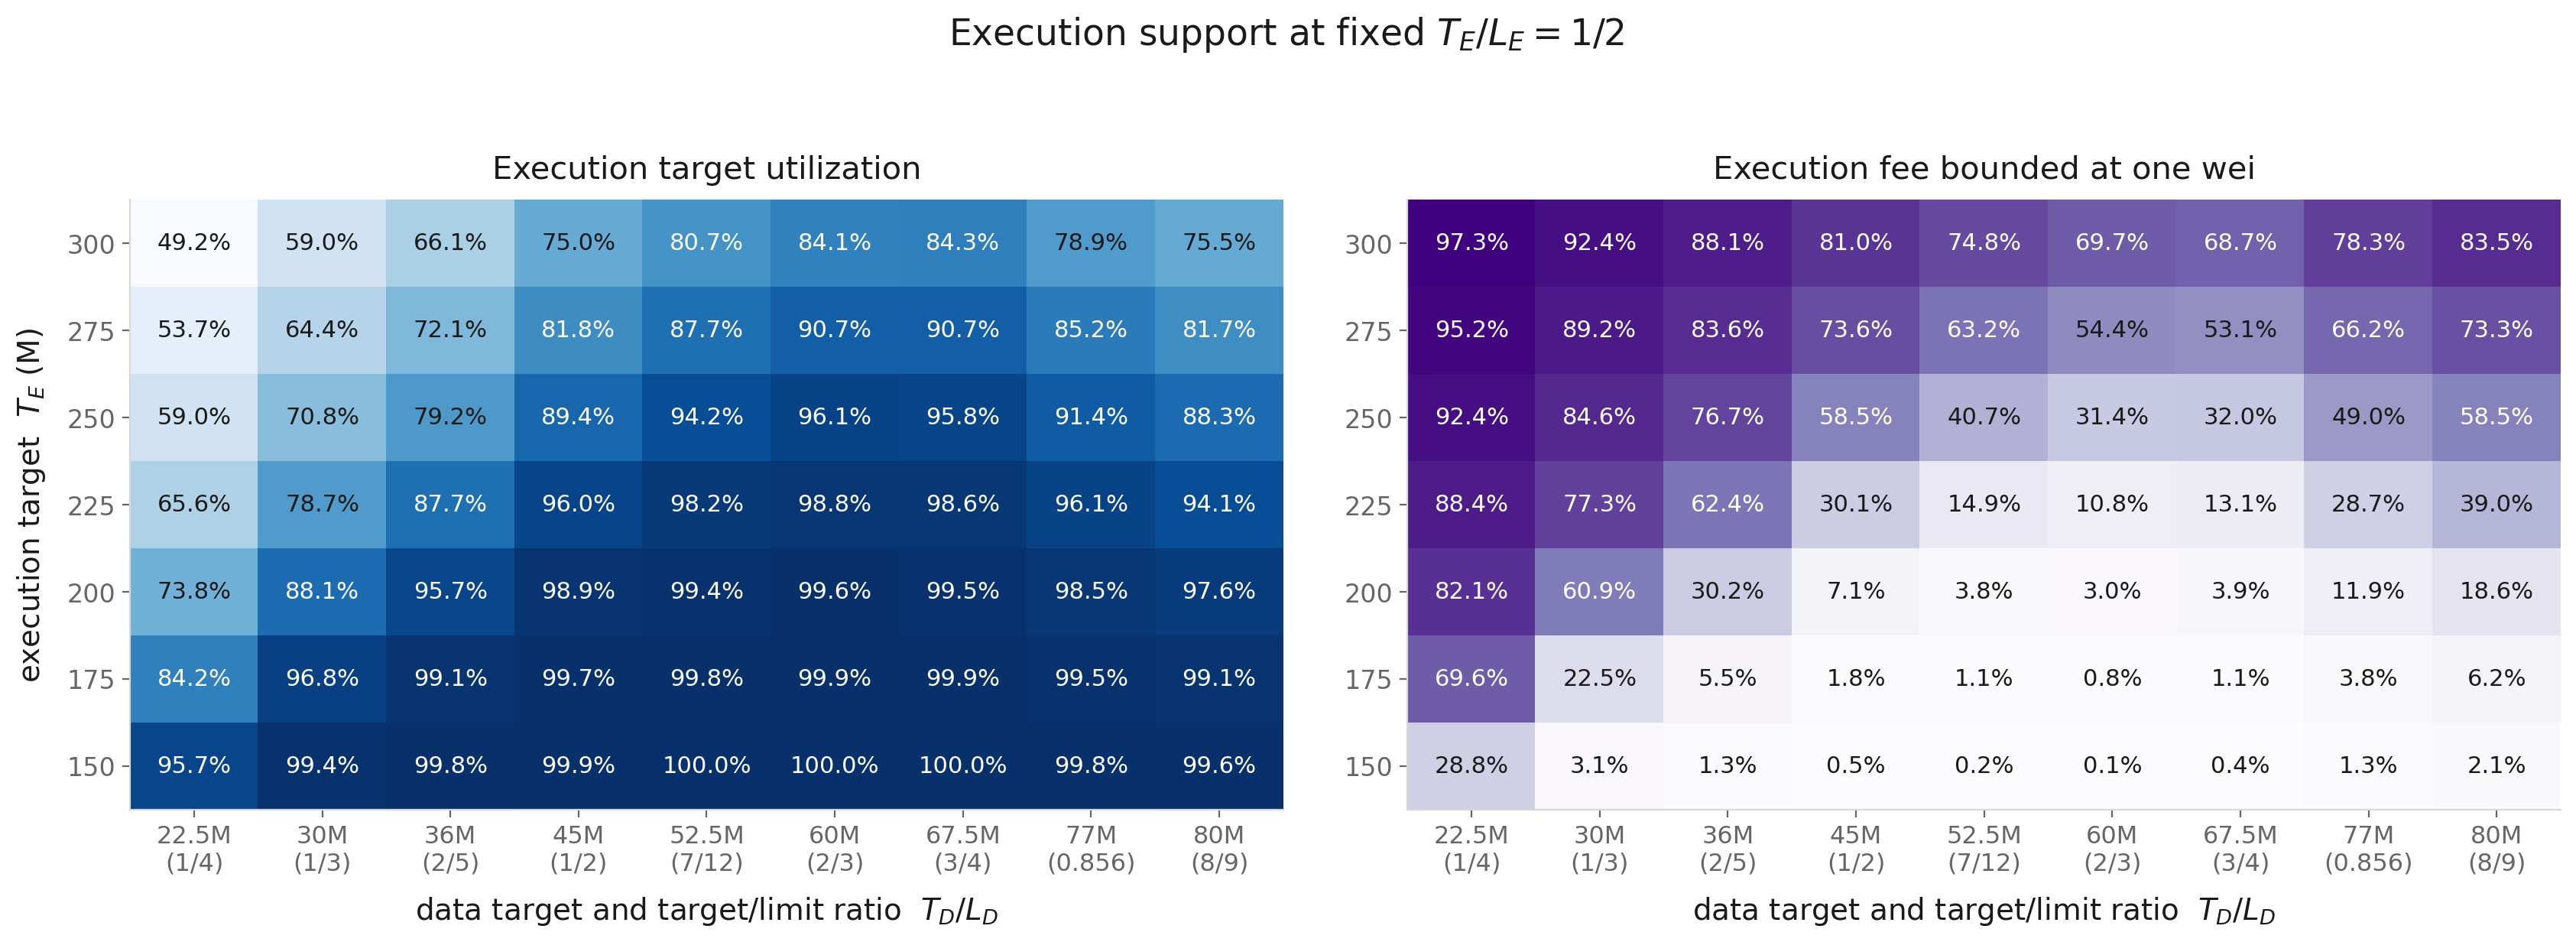

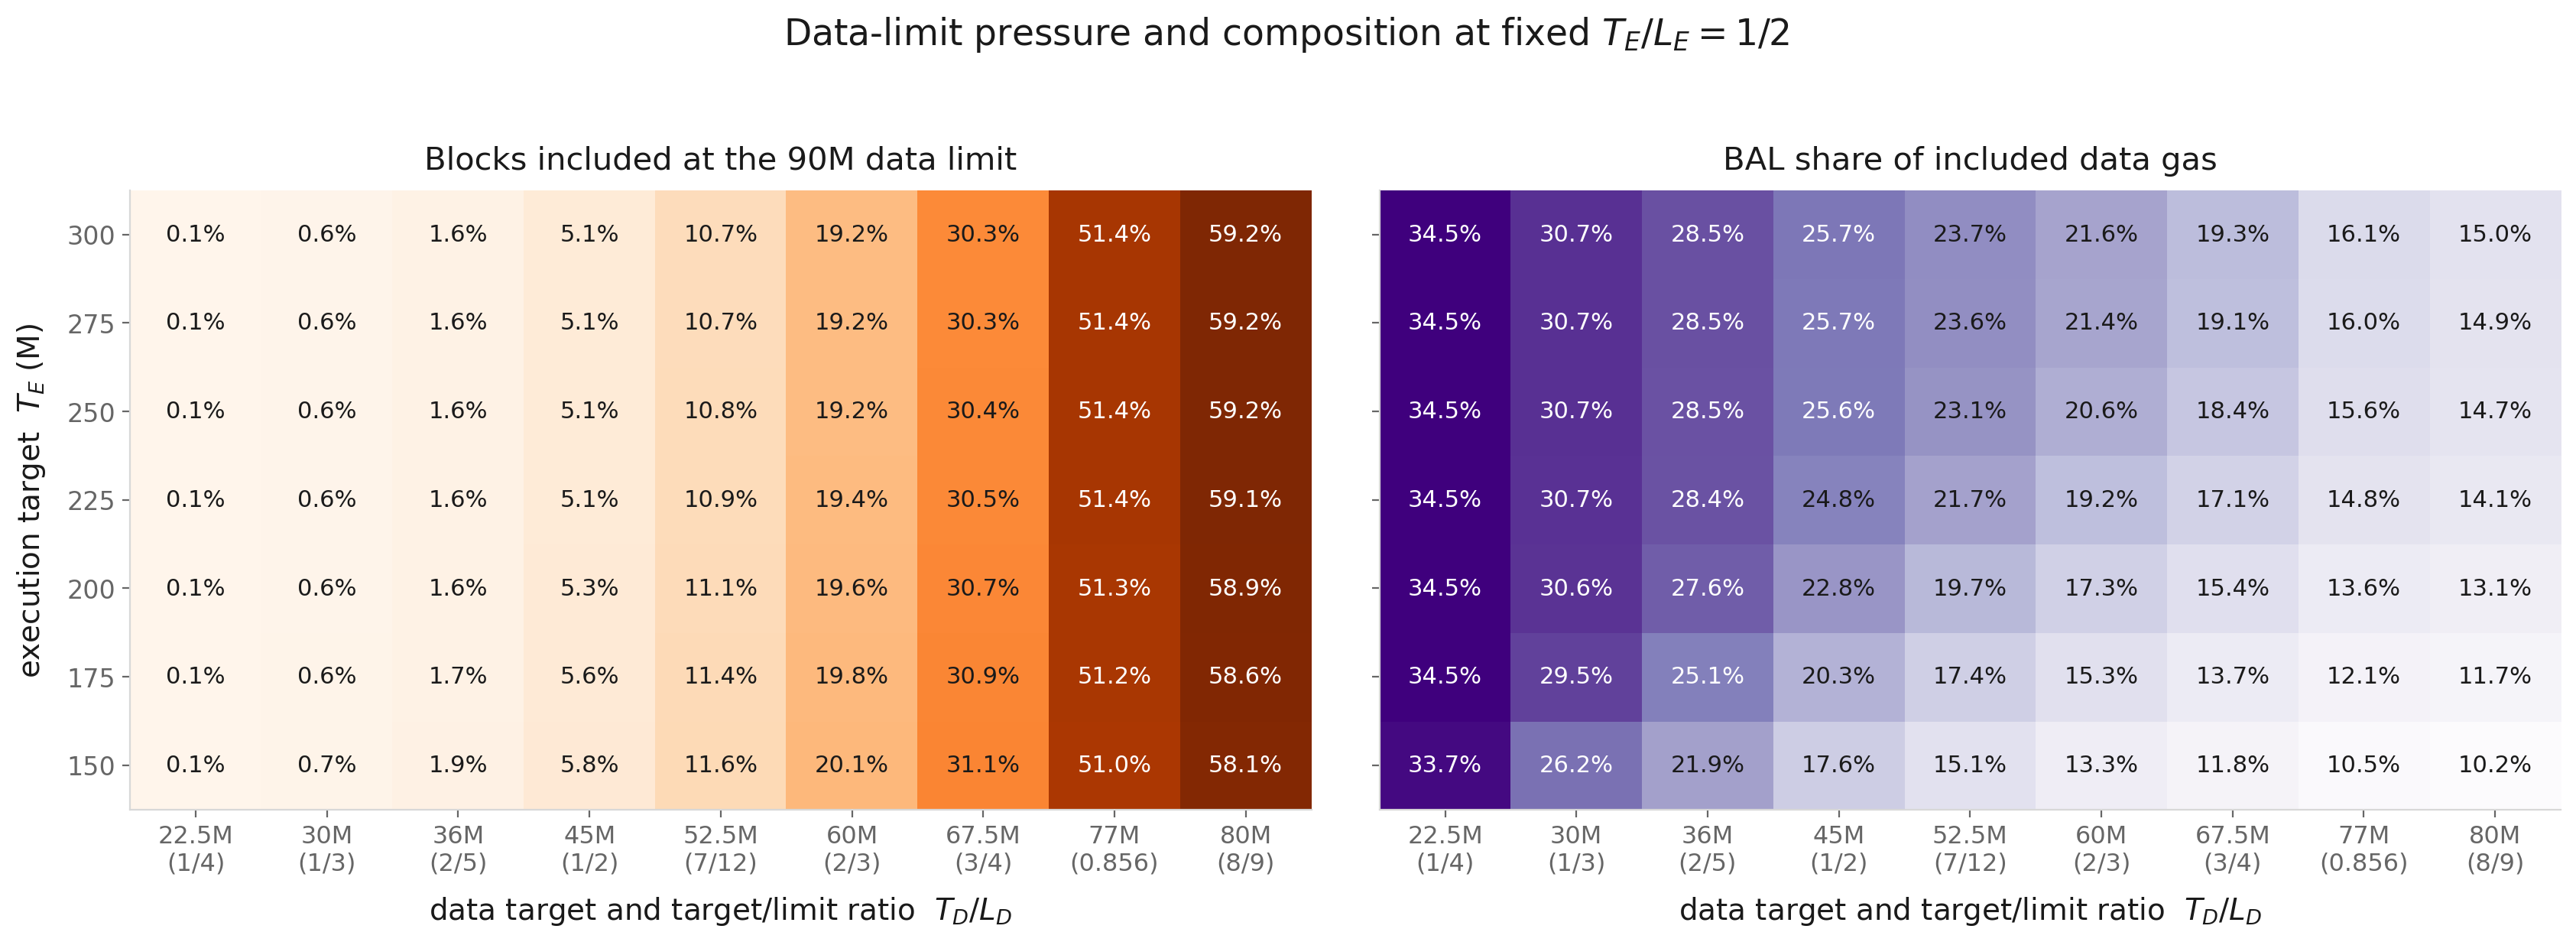

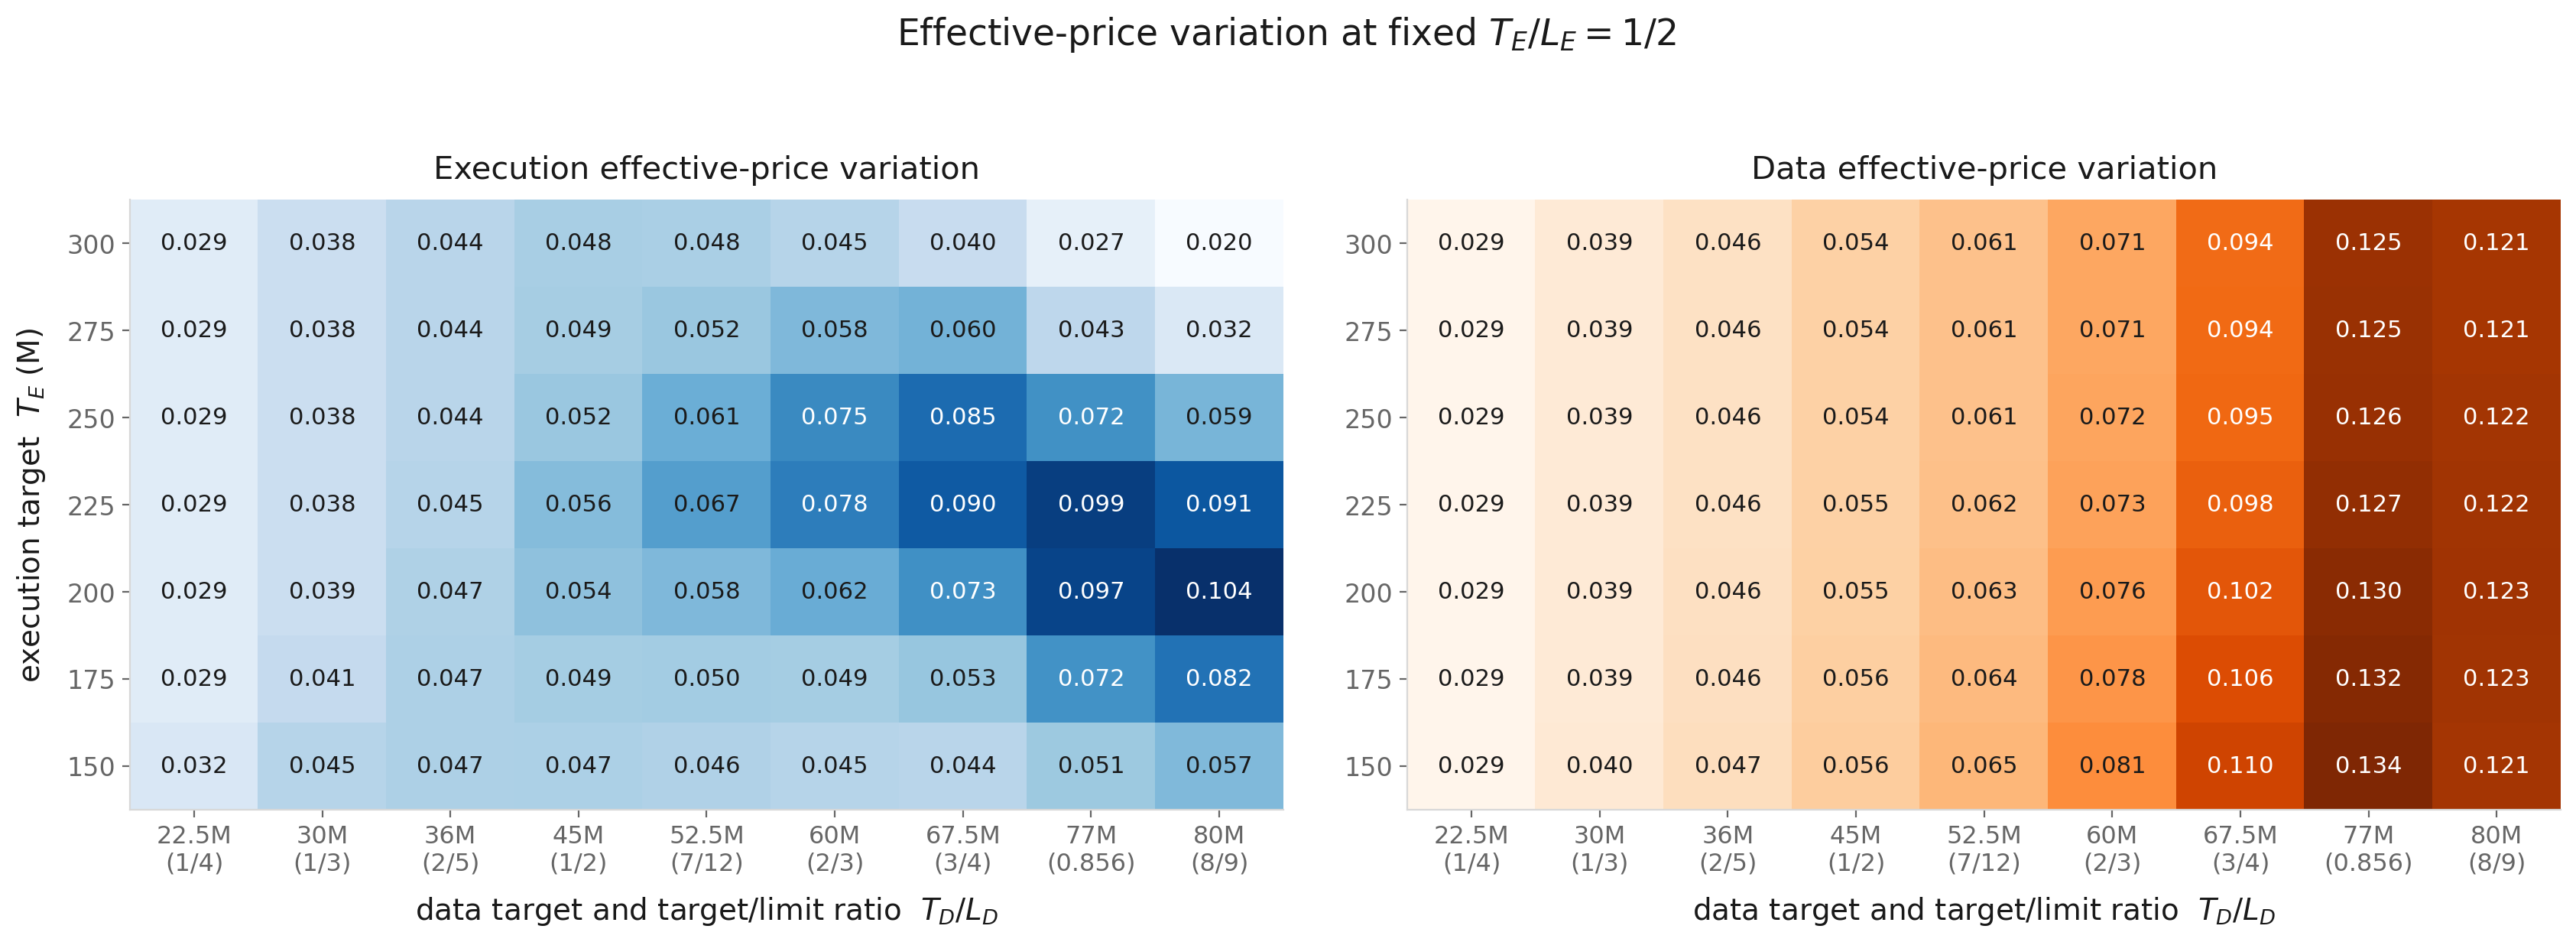

In [3]:
from make_pipeline_figures import figure_design_grids

figure_design_grids(surface)
for name in (
    "dynamic_execution_support_grid.png",
    "dynamic_data_limit_pressure_grid.png",
    "dynamic_price_variation_grid.png",
):
    display(Image(filename=PLOTS_DIR / name))

## Reproduce headline target-grid results

The table below reconstructs the E300 row. The E300/D80 diagnostic separately checks total offered data before hard-limit clipping; this is the 119.5M figure used in the report.

In [4]:
e300 = grid[np.isclose(grid["execution_target"], 300e6)].copy()
e300["data_target_M"] = e300["data_target"] / 1e6
e300["delivered_execution_M"] = e300["included_execution"] / 1e6
display(
    e300[[
        "data_target_M", "execution_fill", "execution_floor_bounded_fraction",
        "delivered_execution_M", "data_limit_hit_fraction",
        "execution_price_sd", "data_price_sd",
    ]]
)

e300_d80 = e300[np.isclose(e300["data_target"], 80e6)].iloc[0]
offered_data = (
    e300_d80["static_data_offered"]
    + e300_d80["bal_execution_data_offered"]
    + e300_d80["bal_state_data_offered"]
)
print(f"E300/D80 offered data: {offered_data / 1e6:.1f}M")
print(f"E300/D80 data-limit blocks: {e300_d80.data_limit_hit_fraction:.1%}")
print(f"E300/D80 delivered execution: {e300_d80.included_execution / 1e6:.1f}M")

assert np.isclose(offered_data / 1e6, 119.5, atol=0.06)
assert np.isclose(e300_d80.data_limit_hit_fraction, 0.592, atol=0.001)
assert np.isclose(e300_d80.included_execution / 1e6, 226.4, atol=0.1)

,data_target_M,execution_fill,execution_floor_bounded_fraction,delivered_execution_M,data_limit_hit_fraction,execution_price_sd,data_price_sd
54,22.50,0.491805,0.972538,147.541527,0.001318,0.029221,0.029320
55,29.97,0.590140,0.924049,177.041888,0.005912,0.038204,0.038790
56,36.00,0.660513,0.880809,198.153961,0.015742,0.043946,0.045673
57,45.00,0.750471,0.809826,225.141326,0.050558,0.048455,0.054360
58,52.47,0.807343,0.747978,242.202919,0.107333,0.047897,0.060913
59,60.03,0.840835,0.696598,252.250378,0.191586,0.044881,0.071282
60,67.50,0.843439,0.686693,253.031742,0.303188,0.039746,0.093952
61,77.00,0.788617,0.782696,236.584956,0.513754,0.026743,0.124711
62,80.00,0.754650,0.835224,226.395140,0.592117,0.019670,0.120988


E300/D80 offered data: 119.5M
E300/D80 data-limit blocks: 59.2%
E300/D80 delivered execution: 226.4M


## Handoff

The central surface and the three fixed-ratio report figures are now reproducible. Notebook 3 replaces the row-specific execution limits with one physical execution limit at each propagation-time split.